In [ ]:
!pip install ultralytics scipy opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("YOLO loaded successfully")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO loaded successfully


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d tthien/shanghaitech


Dataset URL: https://www.kaggle.com/datasets/tthien/shanghaitech
License(s): unknown
 93% 308M/333M [00:00<00:00, 881MB/s] 
100% 333M/333M [00:00<00:00, 819MB/s]


In [ ]:
!unzip shanghaitech.zip


Archive:  shanghaitech.zip
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_1.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_10.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_100.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_101.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_102.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_103.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_104.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_105.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_106.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_107.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_108.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_109.mat  
  inflating: ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_11.mat  
  inflating: ShanghaiTech/pa

In [ ]:
import os

BASE_DIR = "yolo_shanghaitech"

paths = [
    f"{BASE_DIR}/images/train",
    f"{BASE_DIR}/labels/train"
]

for p in paths:
    os.makedirs(p, exist_ok=True)

print("YOLO folder structure created")


YOLO folder structure created


In [ ]:
import shutil

src_img_dir = "ShanghaiTech/part_B/train_data/images"
dst_img_dir = "yolo_shanghaitech/images/train"

for img in os.listdir(src_img_dir):
    if img.endswith(".jpg"):
        shutil.copy(
            os.path.join(src_img_dir, img),
            os.path.join(dst_img_dir, img)
        )

print("Images copied successfully")


Images copied successfully


In [ ]:
import scipy.io as sio
import cv2

GT_DIR = "ShanghaiTech/part_B/train_data/ground-truth"
IMG_DIR = "ShanghaiTech/part_B/train_data/images"
LABEL_DIR = "yolo_shanghaitech/labels/train"

BOX_SIZE = 30  # suitable for Part B

for mat_file in os.listdir(GT_DIR):
    if not mat_file.endswith(".mat"):
        continue

    mat_path = os.path.join(GT_DIR, mat_file)
    mat = sio.loadmat(mat_path)

    # Extract head points
    points = mat["image_info"][0][0][0][0][0]

    img_name = mat_file.replace("GT_", "").replace(".mat", ".jpg")
    img_path = os.path.join(IMG_DIR, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w, _ = img.shape

    label_path = os.path.join(
        LABEL_DIR,
        img_name.replace(".jpg", ".txt")
    )

    with open(label_path, "w") as f:
        for x, y in points:
            x_min = max(0, x - BOX_SIZE // 2)
            y_min = max(0, y - BOX_SIZE // 2)
            x_max = min(w, x + BOX_SIZE // 2)
            y_max = min(h, y + BOX_SIZE // 2)

            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h
            bw = (x_max - x_min) / w
            bh = (y_max - y_min) / h

            f.write(f"0 {x_center} {y_center} {bw} {bh}\n")

print("Annotation conversion completed")


Annotation conversion completed


In [ ]:
!ls yolo_shanghaitech/labels/train | head


IMG_100.txt
IMG_101.txt
IMG_102.txt
IMG_103.txt
IMG_104.txt
IMG_105.txt
IMG_106.txt
IMG_107.txt
IMG_108.txt
IMG_109.txt


In [ ]:
!cat yolo_shanghaitech/labels/train/IMG_100.txt


0 0.009632954744397739 0.9717951574569222 0.019265909488795478 0.0390625
0 0.11054279666412015 0.9669250275867923 0.029296875 0.0390625
0 0.17020188757321106 0.9328341184958832 0.029296875 0.0390625
0 0.050883705755029235 0.7883535990153637 0.029296875000000007 0.0390625
0 0.12150058887191231 0.773743209404974 0.029296875 0.0390625
0 0.20429279666412015 0.7542626899244547 0.029296875 0.0390625
0 0.17141942004074356 0.6471198327815973 0.029296875 0.0390625
0 0.18602980965113314 0.6162756769374417 0.029296875 0.0390625
0 0.2809973421186656 0.6795873652491299 0.029296875 0.0390625
0 0.38570513432645787 0.6990678847296494 0.029296875 0.0390625
0 0.3771824070537306 0.7088081444699091 0.029296875 0.0390625
0 0.27856227718360077 0.7591328197945845 0.029296875 0.0390625
0 0.3077830564043799 0.7964704821322468 0.029296875 0.0390625
0 0.2834324070537306 0.8240678847296494 0.029296875 0.0390625
0 0.2809973421186656 0.8695224301841948 0.029296875 0.0390625
0 0.5537246148459384 0.692574378236143 0.

In [ ]:
print(
    "Images:", len(os.listdir("yolo_shanghaitech/images/train")),
    "Labels:", len(os.listdir("yolo_shanghaitech/labels/train"))
)


Images: 400 Labels: 400


In [ ]:
import os

BASE_DIR = "yolo_shanghaitech"

os.makedirs(f"{BASE_DIR}/images/val", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels/val", exist_ok=True)

print("Validation folders created")


Validation folders created


In [ ]:
import random
import shutil

IMG_TRAIN = "yolo_shanghaitech/images/train"
LBL_TRAIN = "yolo_shanghaitech/labels/train"
IMG_VAL = "yolo_shanghaitech/images/val"
LBL_VAL = "yolo_shanghaitech/labels/val"

images = os.listdir(IMG_TRAIN)
random.shuffle(images)

val_count = int(0.2 * len(images))
val_images = images[:val_count]

for img in val_images:
    shutil.move(
        os.path.join(IMG_TRAIN, img),
        os.path.join(IMG_VAL, img)
    )

    label = img.replace(".jpg", ".txt")
    shutil.move(
        os.path.join(LBL_TRAIN, label),
        os.path.join(LBL_VAL, label)
    )

print(f"Moved {val_count} images to validation set")


Moved 80 images to validation set


In [ ]:
print("Train images:", len(os.listdir(IMG_TRAIN)))
print("Val images:", len(os.listdir(IMG_VAL)))

print("Train labels:", len(os.listdir(LBL_TRAIN)))
print("Val labels:", len(os.listdir(LBL_VAL)))


Train images: 320
Val images: 80
Train labels: 320
Val labels: 80


In [ ]:
yaml_content = """
path: yolo_shanghaitech
train: images/train
val: images/val

names:
  0: person
"""

with open("shanghaitech.yaml", "w") as f:
    f.write(yaml_content)

print("shanghaitech.yaml created")


shanghaitech.yaml created


In [ ]:
!cat shanghaitech.yaml



path: yolo_shanghaitech
train: images/train
val: images/val

names:
  0: person


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="shanghaitech.yaml",
    epochs=150,
    imgsz=640,
    batch=15,
    device=0
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=shanghaitech.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ed4f94c8860>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
print("Custom-trained YOLO loaded")


Custom-trained YOLO loaded



image 1/1 /content/yolo_shanghaitech/images/val/IMG_358.jpg: 480x640 22 persons, 1 handbag, 1 baseball glove, 16.6ms
Speed: 3.4ms preprocess, 16.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


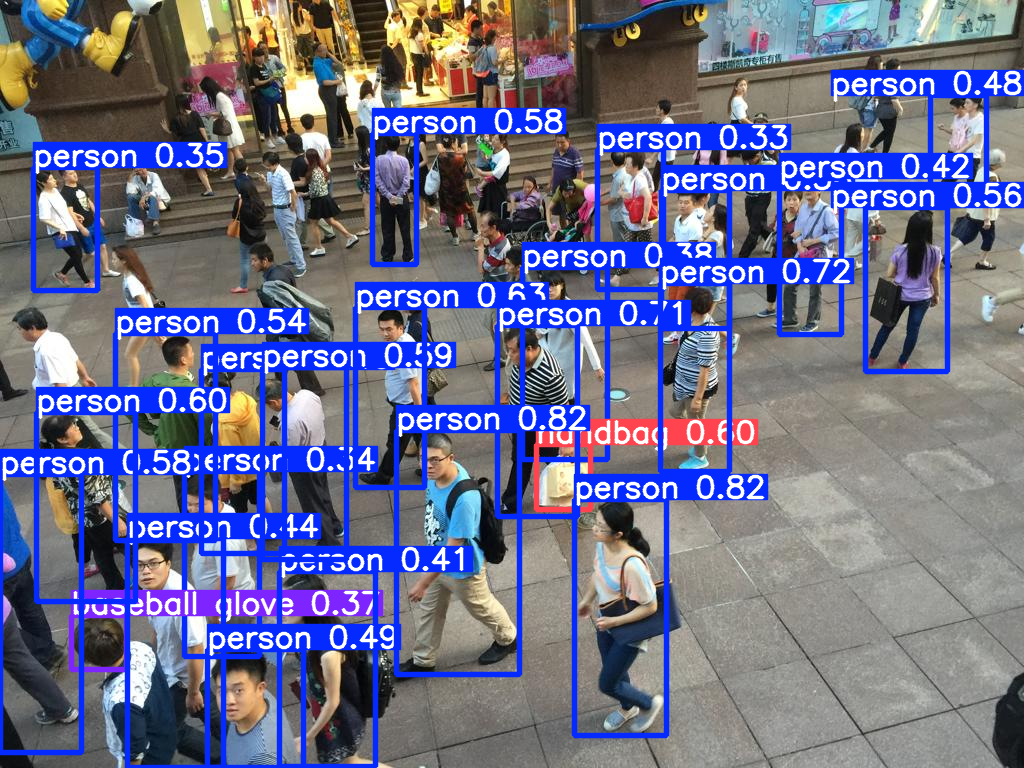

In [ ]:
default_model = YOLO("yolov8n.pt")
default_results = default_model(img_path, conf=0.3)
default_results[0].show()



image 1/1 /content/yolo_shanghaitech/images/val/IMG_358.jpg: 480x640 79 persons, 6.5ms
Speed: 2.4ms preprocess, 6.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


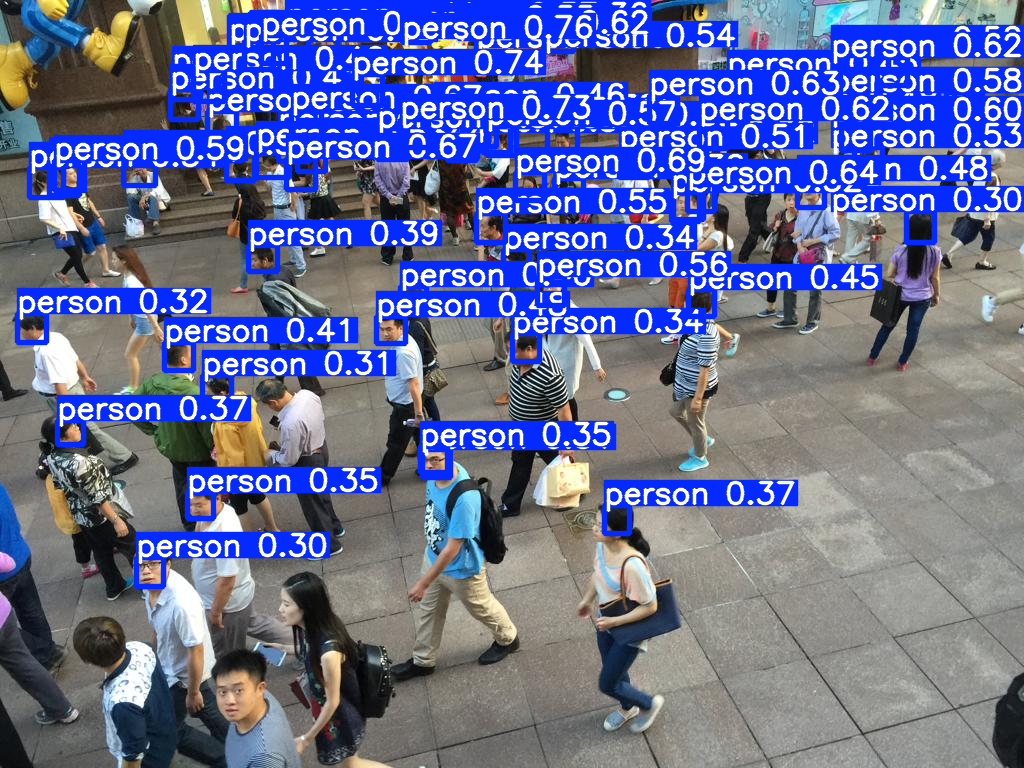

In [ ]:
import random
import os

val_img_dir = "yolo_shanghaitech/images/val"
img_name = random.choice(os.listdir(val_img_dir))
img_path = os.path.join(val_img_dir, img_name)

results = model(img_path, conf=0.3)
results[0].show()


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val(
    data="shanghaitech.yaml",
    imgsz=640,
    conf=0.3,
    iou=0.5,
    device=0
)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3306.1±959.5 MB/s, size: 141.7 KB)
val: Scanning /content/yolo_shanghaitech/labels/val.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 22.4Mit/s 0.0s
val: /content/yolo_shanghaitech/images/val/IMG_183.jpg: 8 duplicate labels removed
val: /content/yolo_shanghaitech/images/val/IMG_374.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8s/it 8.9s
                   all         80       8602      0.817      0.555      0.692      0.284
Speed: 4.2ms preprocess, 4.7ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Precision: 0.8172797262617622
Recall: 0.5553359683794467
mAP@0.5: 0.6923379103477337
mAP@0.5:0.95: 0.28445087645136363
